# Post-Quantum Cryptography (PQC) Adoption Analysis
Analyses PQC adoption across all scanned domains (~900 k good responses). Every chart is produced twice: once for **all** domains and once excluding any domain served via a CDN.

## 1 — Setup

In [110]:
import sys, os
sys.path.insert(0, os.path.abspath('../database'))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from import_data import db_connect, start_docker

plt.rcParams.update({
    'figure.dpi':        130,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.35,
    'font.size':         11,
})
CMAP         = plt.get_cmap('tab20')
PQC_COLOUR   = '#2196F3'
NOPQC_COLOUR = '#E0E0E0'

## 2 — Connect to database

In [111]:
start_docker()
conn   = db_connect()
cursor = conn.cursor(dictionary=True)
print('Connected.')

Starting Docker container.
Waiting for db to respond... success!
Connected.


## 3 — Seed protocols tableCalls `seed_protocols` from `Protocol_import.py` to ensure every known PQC protocol
has its `key_size` and `Protocol_Type` set. Safe to re-run.

In [112]:
from Protocol_import import seed_protocols

seed_cursor = conn.cursor(dictionary=True)
inserted, updated = seed_protocols(seed_cursor)
conn.commit()
seed_cursor.close()
print(f'Inserted: {inserted}  Updated: {updated}')

cursor.execute('SELECT protocol_name, key_size, Protocol_Type FROM protocols ORDER BY id')
pd.DataFrame(cursor.fetchall())

  [UPDATE] 'X25519MLKEM768' -> key_size=768, type=hybrid
  [UPDATE] 'SecP256r1MLKEM768' -> key_size=768, type=hybrid
  [UPDATE] 'SecP384r1MLKEM1024' -> key_size=1024, type=hybrid
  [UPDATE] 'MLKEM512' -> key_size=512, type=pure
  [UPDATE] 'MLKEM768' -> key_size=768, type=pure
  [UPDATE] 'MLKEM1024' -> key_size=1024, type=pure
  [UPDATE] 'X25519Kyber768Draft00' -> key_size=768, type=hybrid
  [UPDATE] 'SecP256r1Kyber768Draft00' -> key_size=768, type=hybrid
  [UPDATE] 'curveSM2MLKEM768' -> key_size=768, type=hybrid
Inserted: 0  Updated: 9


,protocol_name,key_size,Protocol_Type
0,X25519MLKEM768,768,hybrid
1,X25519Kyber768Draft00,768,hybrid
2,SecP256r1MLKEM768,768,hybrid
3,SecP384r1MLKEM1024,1024,hybrid
4,MLKEM1024,1024,pure
5,MLKEM512,512,pure
6,MLKEM768,768,pure
7,SecP256r1Kyber768Draft00,768,hybrid
8,curveSM2MLKEM768,768,hybrid


## 4 — Load dataPulls every row from `good_responses` and the protocol join. Then creates a CDN-excluded subset used throughout the notebook.

In [113]:
print('Loading good_responses ...', end=' ', flush=True)
cursor.execute("""
    SELECT domain_rank, has_pqc, continent, region,
           sector, cdn_provider, tls_version, cipher_suite
    FROM good_responses
""")
df = pd.DataFrame(cursor.fetchall())
df['has_pqc'] = df['has_pqc'].astype(bool)
print(f'done  ({len(df):,} rows)')

print('Loading protocols ...', end=' ', flush=True)
cursor.execute("""
    SELECT rp.domain_rank, p.protocol_name, p.key_size, p.Protocol_Type AS protocol_type
    FROM response_protocols rp
    JOIN protocols p ON p.id = rp.protocol_id
""")
df_proto = pd.DataFrame(cursor.fetchall())
print(f'done  ({len(df_proto):,} rows)')

# CDN-excluded subsets
df_nocdn       = df[df['cdn_provider'].isna()].copy()
df_proto_nocdn = df_proto[df_proto['domain_rank'].isin(df_nocdn['domain_rank'])].copy()

# CDN-only subsets
df_cdnonly       = df[df['cdn_provider'].notna()].copy()
df_proto_cdnonly = df_proto[df_proto['domain_rank'].isin(df_cdnonly['domain_rank'])].copy()

n_total_cdnonly = len(df_cdnonly)
n_pqc_cdnonly   = int(df_cdnonly['has_pqc'].sum())

n_total        = len(df)
n_pqc          = int(df['has_pqc'].sum())
n_total_nocdn  = len(df_nocdn)
n_pqc_nocdn    = int(df_nocdn['has_pqc'].sum())

print(f'\nAll domains      : {n_total:,}  |  PQC: {n_pqc:,}  ({n_pqc/n_total*100:.2f}%)')
print(f'No-CDN domains   : {n_total_nocdn:,}  |  PQC: {n_pqc_nocdn:,}  ({n_pqc_nocdn/n_total_nocdn*100:.2f}%)')
print(f'CDN-only domains : {n_total_cdnonly:,}  |  PQC: {n_pqc_cdnonly:,}  ({n_pqc_cdnonly/n_total_cdnonly*100:.2f}%)')


Loading good_responses ... done  (822,849 rows)
Loading protocols ... done  (734,228 rows)

All domains      : 822,849  |  PQC: 382,494  (46.48%)
No-CDN domains   : 519,734  |  PQC: 107,025  (20.59%)
CDN-only domains : 303,115  |  PQC: 275,469  (90.88%)


## 5 — Data coverageOf all good responses, how many have a sector, region, and continent populated. Shown for both all domains and the no-CDN subset.

--- All domains (n=822,849) ---


,Field,Populated,Missing,Coverage
0,sector,"91,886","730,963",11.2%
1,region,"627,303","195,546",76.2%
2,continent,"618,398","204,451",75.2%


  PQC-enabled sites                        : 382,494
  Avg PQC mechanisms per PQC-enabled site  : 1.92

--- No-CDN domains (n=519,734) ---


,Field,Populated,Missing,Coverage
0,sector,"57,593","462,141",11.1%
1,region,"519,234",500,99.9%
2,continent,"513,401","6,333",98.8%


  PQC-enabled sites                        : 107,025
  Avg PQC mechanisms per PQC-enabled site  : 1.72



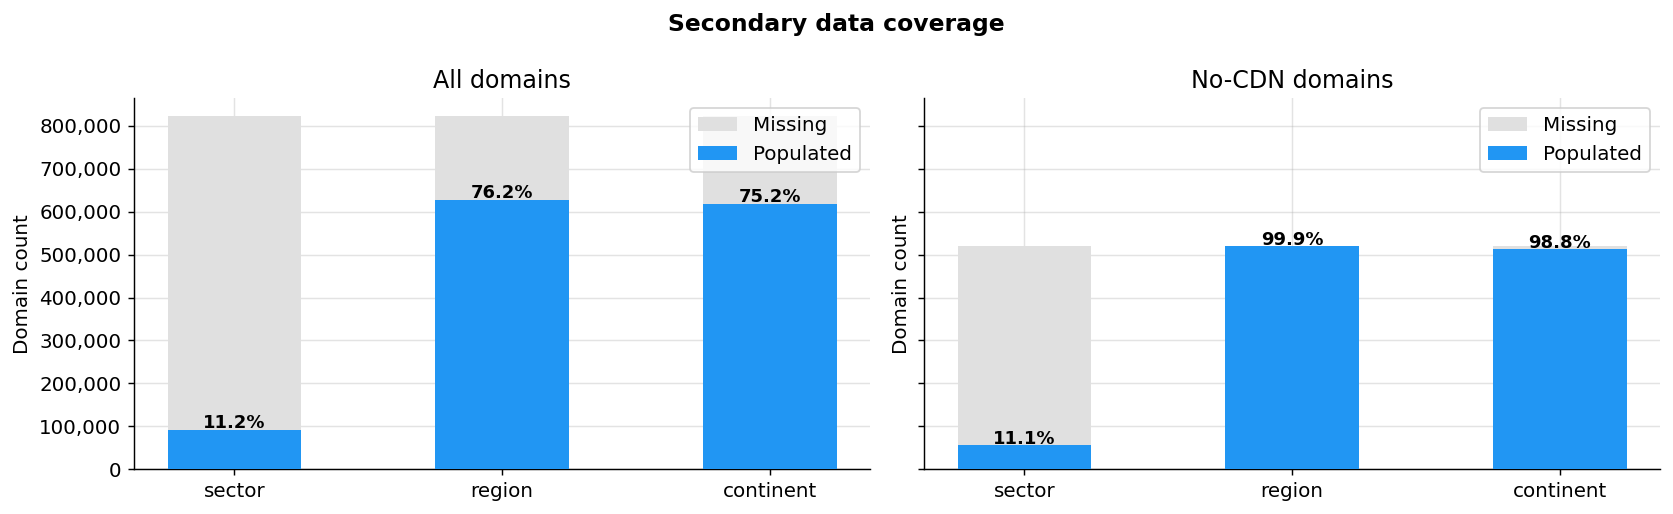

In [114]:
def coverage(col, data):
    filled = data[col].notna() & (data[col].astype(str).str.strip() != '') & (data[col].astype(str) != 'None')
    n = int(filled.sum())
    return n, n / len(data) * 100

def avg_protocols_per_pqc_site(proto, data):
    """Mean number of distinct PQC mechanisms per PQC-enabled domain."""
    pqc_ranks = set(data.loc[data['has_pqc'], 'domain_rank'])
    counts = (proto[proto['domain_rank'].isin(pqc_ranks)]
              .groupby('domain_rank')['protocol_name'].nunique())
    return counts.mean() if not counts.empty else 0

for label, data, proto in [
        ('All domains',    df,       df_proto),
        ('No-CDN domains', df_nocdn, df_proto_nocdn),
    ]:
    total = len(data)
    rows = []
    for col in ('sector', 'region', 'continent'):
        n, pct = coverage(col, data)
        rows.append({'Field': col, 'Populated': f'{n:,}', 'Missing': f'{total-n:,}', 'Coverage': f'{pct:.1f}%'})
    avg_mech = avg_protocols_per_pqc_site(proto, data)
    pqc_sites = int(data['has_pqc'].sum())
    print(f'--- {label} (n={total:,}) ---')
    display(pd.DataFrame(rows))
    print(f'  PQC-enabled sites                        : {pqc_sites:,}')
    print(f'  Avg PQC mechanisms per PQC-enabled site  : {avg_mech:.2f}\n')

# charts
fields = ['sector', 'region', 'continent']
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, (label, data) in zip(axes, [('All domains', df), ('No-CDN domains', df_nocdn)]):
    total  = len(data)
    filled = [coverage(c, data)[0] for c in fields]
    x = np.arange(len(fields))
    ax.bar(x, [total]*3, color=NOPQC_COLOUR, label='Missing', width=0.5, zorder=3)
    ax.bar(x, filled,    color=PQC_COLOUR,   label='Populated', width=0.5, zorder=3)
    ax.set_xticks(x); ax.set_xticklabels(fields)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
    ax.set_ylabel('Domain count'); ax.set_title(label)
    ax.legend()
    for xi, n, pct in zip(x, filled, [coverage(c, data)[1] for c in fields]):
        ax.text(xi, n + total*0.005, f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.suptitle('Secondary data coverage', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pqc_coverage.png', bbox_inches='tight')
plt.show()

## 6 — Overall PQC adoption

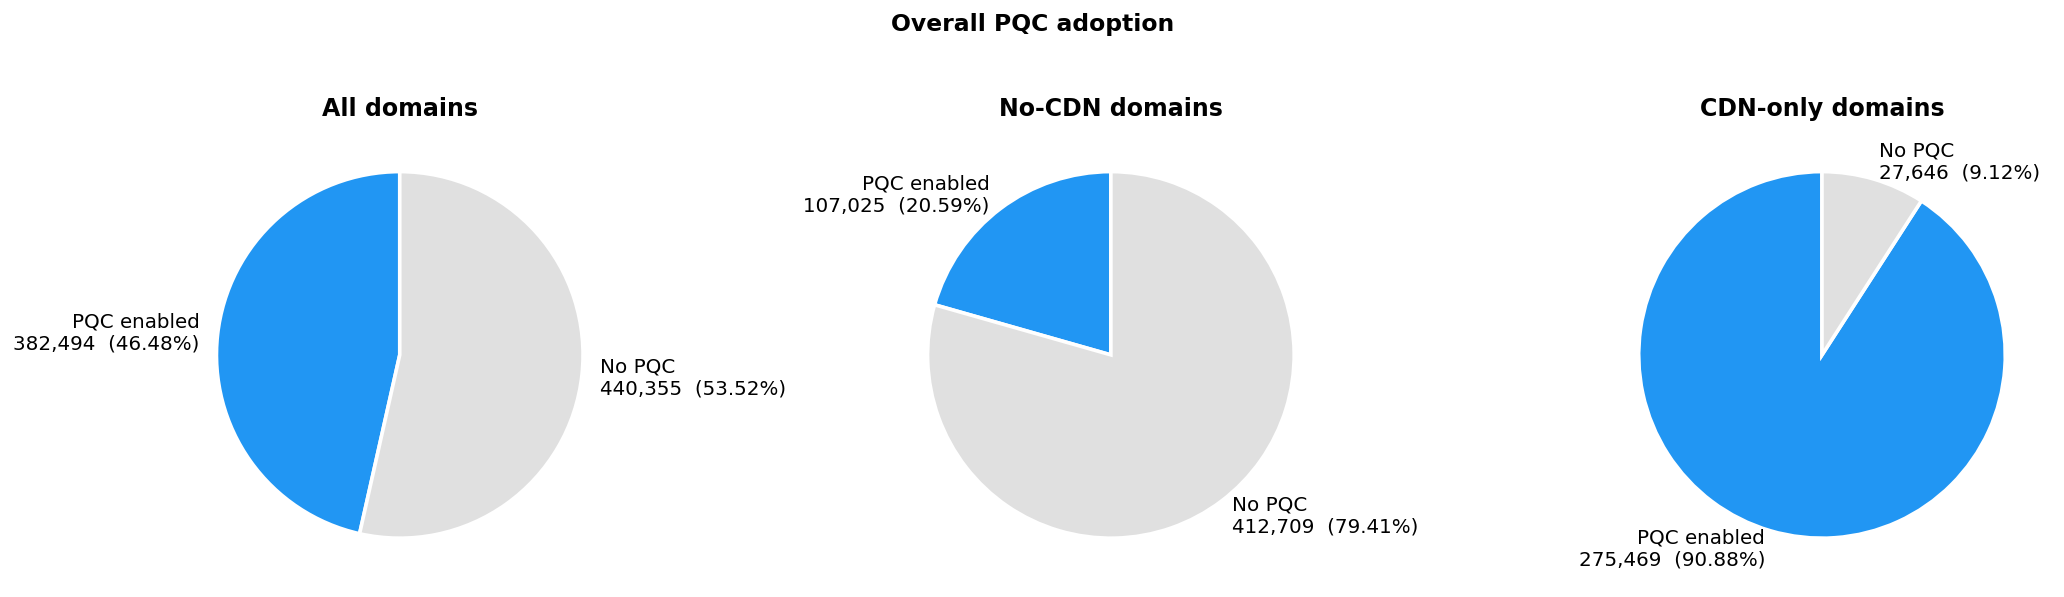

In [115]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (label, total, pqc) in zip(axes, [
        ('All domains',    n_total,        n_pqc),
        ('No-CDN domains', n_total_nocdn,  n_pqc_nocdn),
        ('CDN-only domains', n_total_cdnonly, n_pqc_cdnonly),
    ]):
    sizes  = [pqc, total - pqc]
    labels = [f'PQC enabled\n{pqc:,}  ({pqc/total*100:.2f}%)',
              f'No PQC\n{total-pqc:,}  ({(total-pqc)/total*100:.2f}%)']
    ax.pie(sizes, labels=labels, colors=[PQC_COLOUR, NOPQC_COLOUR],
           startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
    ax.set_title(label, fontweight='bold')
plt.suptitle('Overall PQC adoption', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pqc_overall.png', bbox_inches='tight')
plt.show()

## 7 — Helper function

In [116]:
def adoption_by_col(col, data, min_count=5):
    clean = data[data[col].notna() & (data[col].astype(str) != 'None')].copy()
    grp = clean.groupby(col)['has_pqc'].agg(['sum', 'count']).reset_index()
    grp.columns = [col, 'pqc_count', 'total']
    grp = grp[grp['total'] >= min_count].copy()
    grp['pqc_rate'] = grp['pqc_count'] / grp['total'] * 100
    return grp.sort_values('pqc_rate', ascending=False)


def hbar_chart(ax, grp, col, label, colours=None):
    if colours is None:
        colours = [CMAP(i) for i in np.linspace(0, 1, len(grp))]
    bars = ax.barh(grp[col], grp['pqc_rate'], color=colours, zorder=3)
    for bar, rate, tot in zip(bars, grp['pqc_rate'], grp['total']):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                f'{rate:.1f}%  (n={tot:,})', va='center', fontsize=9)
    mx = grp['pqc_rate'].max() if not grp.empty else 10
    ax.set_xlim(0, mx * 1.5 + 2)
    ax.set_xlabel('PQC adoption rate (%)')
    ax.set_title(label)

## 8 — Adoption by continent

### Adoption by continent — All domains

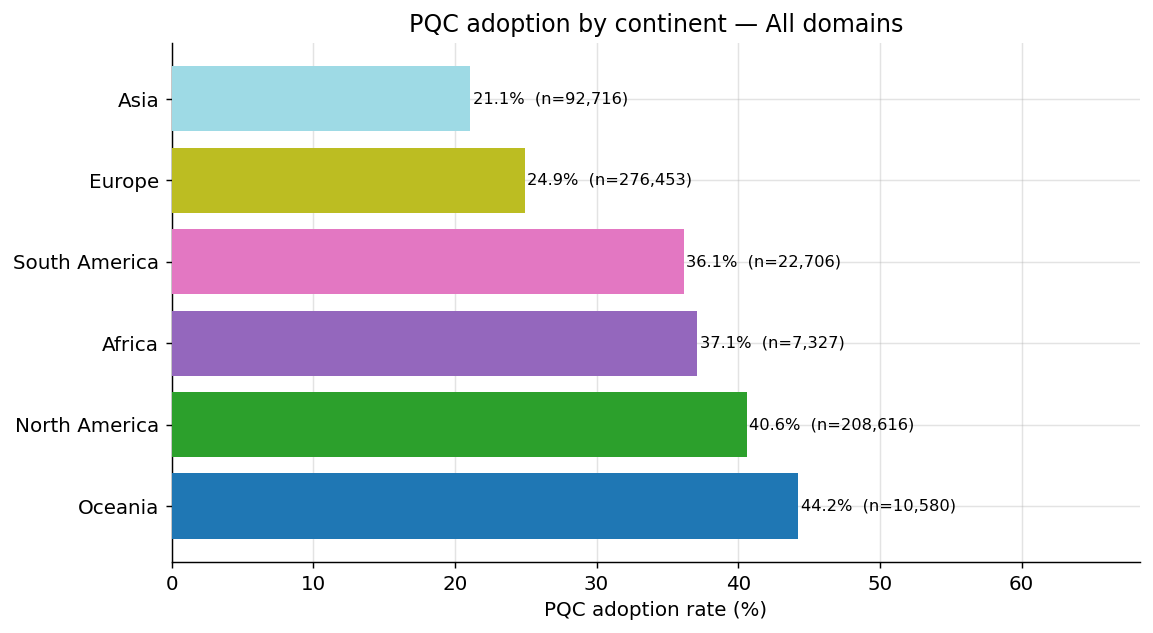

In [117]:
cont = adoption_by_col('continent', df, min_count=1)
fig, ax = plt.subplots(figsize=(9, 5))
hbar_chart(ax, cont, 'continent', 'PQC adoption by continent — All domains')
plt.tight_layout()
plt.savefig('pqc_by_continent_all.png', bbox_inches='tight')
plt.show()

## Rank filter
Set `RANK_LIMIT` to restrict sector and region charts to the top N domains by rank. Set to `None` to use all data.

Examples: `1_000`, `10_000`, `100_000`, `1_000_000`, `None`

In [118]:
# ── Change this value to filter sector and region charts ──────────────────
RANK_LIMIT = None   # None = all data  |  e.g. 100_000 = top 100 k domains
# ─────────────────────────────────────────────────────────────────────────

def apply_rank(data):
    """Return data filtered to domain_rank <= RANK_LIMIT, or unfiltered if RANK_LIMIT is None."""
    if RANK_LIMIT is None:
        return data
    return data[data['domain_rank'] <= RANK_LIMIT].copy()

rank_label = f'top {RANK_LIMIT:,}' if RANK_LIMIT is not None else 'all'
print(f'RANK_LIMIT = {RANK_LIMIT}  →  using {rank_label} domains for sector / region charts')

RANK_LIMIT = None  →  using all domains for sector / region charts


## 9 — Adoption by sector

### Adoption by sector — All domains

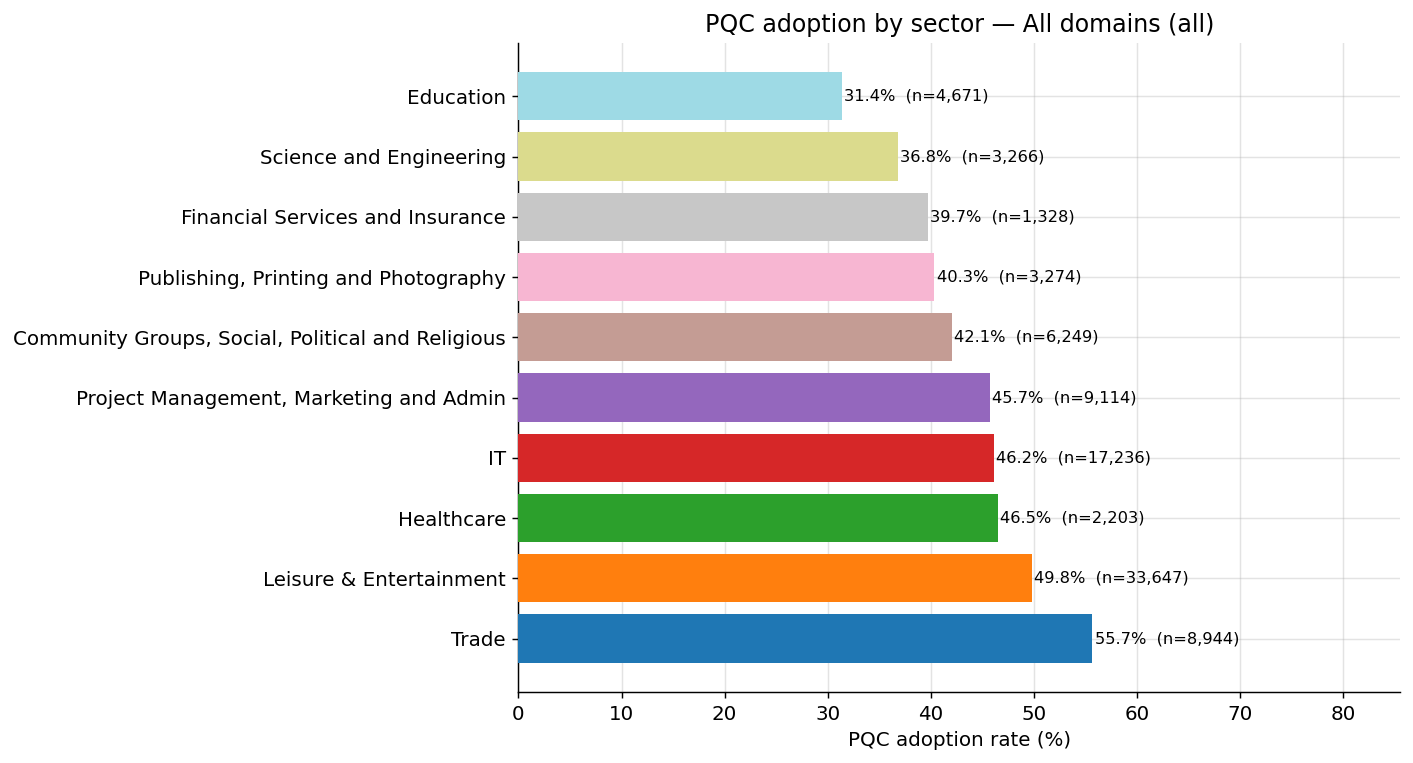

In [119]:
df_sec = apply_rank(df)
sec = adoption_by_col('sector', df_sec, min_count=1000)
fig, ax = plt.subplots(figsize=(11, max(6, len(sec)*0.45+1)))
hbar_chart(ax, sec, 'sector', f'PQC adoption by sector — All domains ({rank_label})')
plt.tight_layout()
plt.savefig(f'pqc_by_sector_all_{rank_label.replace(" ","_")}.png', bbox_inches='tight')
plt.show()

### Adoption by sector — No-CDN domains

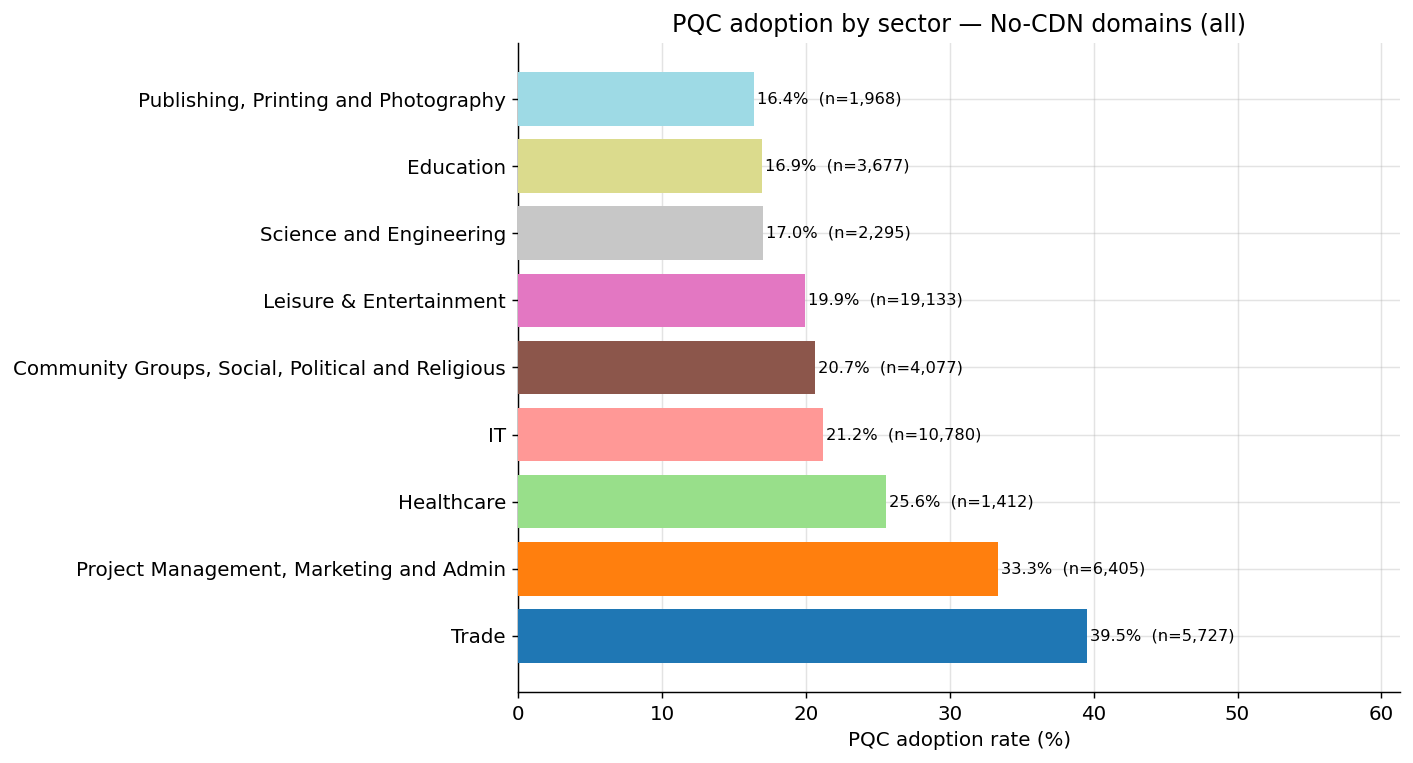

In [120]:
df_sec_nc = apply_rank(df_nocdn)
sec = adoption_by_col('sector', df_sec_nc, min_count=1000)
fig, ax = plt.subplots(figsize=(11, max(6, len(sec)*0.45+1)))
hbar_chart(ax, sec, 'sector', f'PQC adoption by sector — No-CDN domains ({rank_label})')
plt.tight_layout()
plt.savefig(f'pqc_by_sector_nocdn_{rank_label.replace(" ","_")}.png', bbox_inches='tight')
plt.show()

### Adoption by sector — CDN-only domains

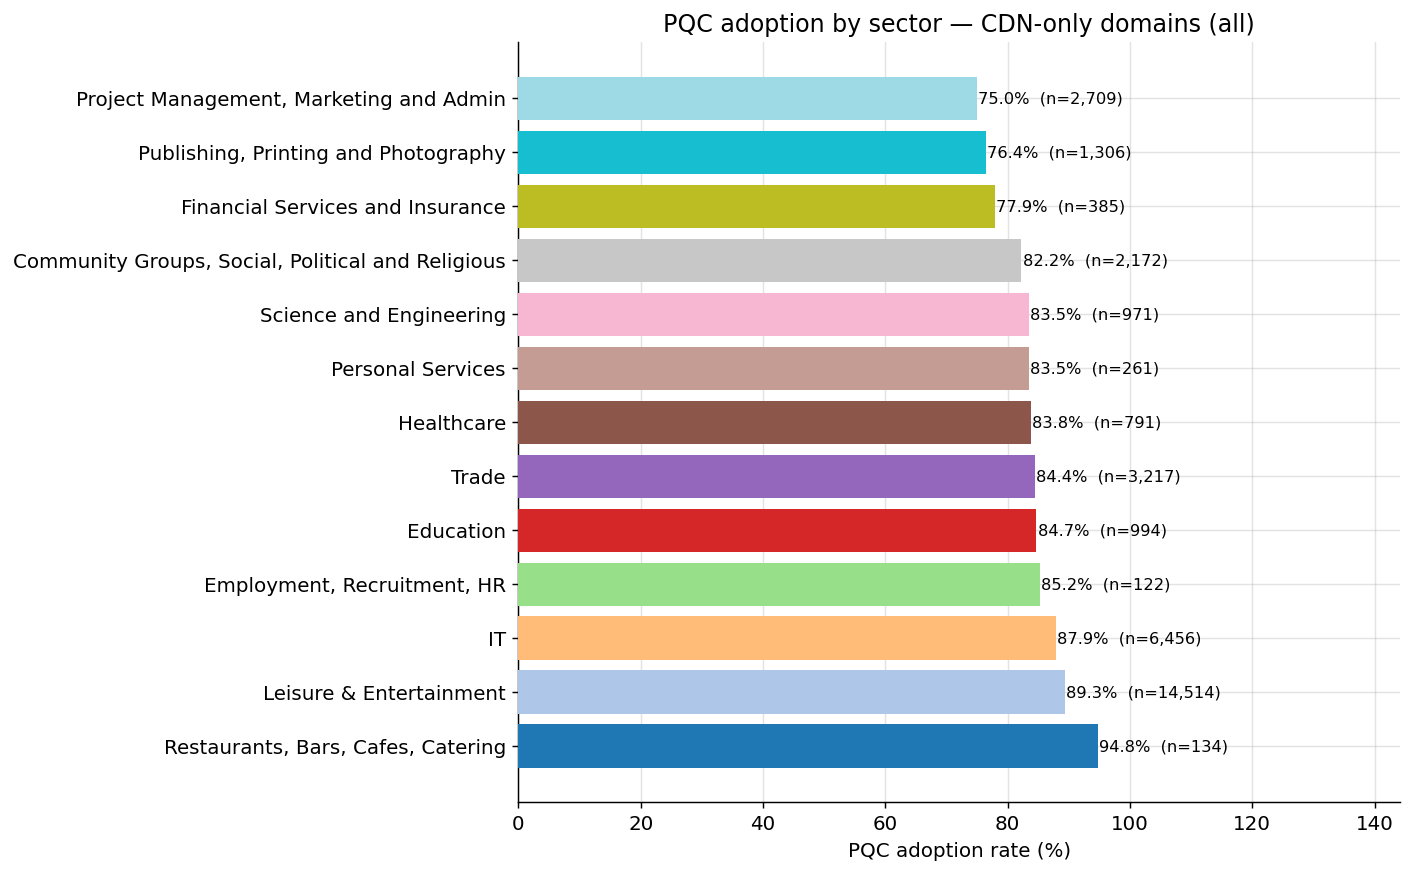

In [132]:
df_sec_cdn = apply_rank(df_cdnonly)
sec = adoption_by_col('sector', df_sec_cdn, min_count=100)
fig, ax = plt.subplots(figsize=(11, max(6, len(sec)*0.45+1)))
hbar_chart(ax, sec, 'sector', f'PQC adoption by sector — CDN-only domains ({rank_label})')
plt.tight_layout()
plt.savefig(f'pqc_by_sector_cdnonly_{rank_label.replace(" ","_")}.png', bbox_inches='tight')
plt.show()

## 10 — Adoption by CDN provider

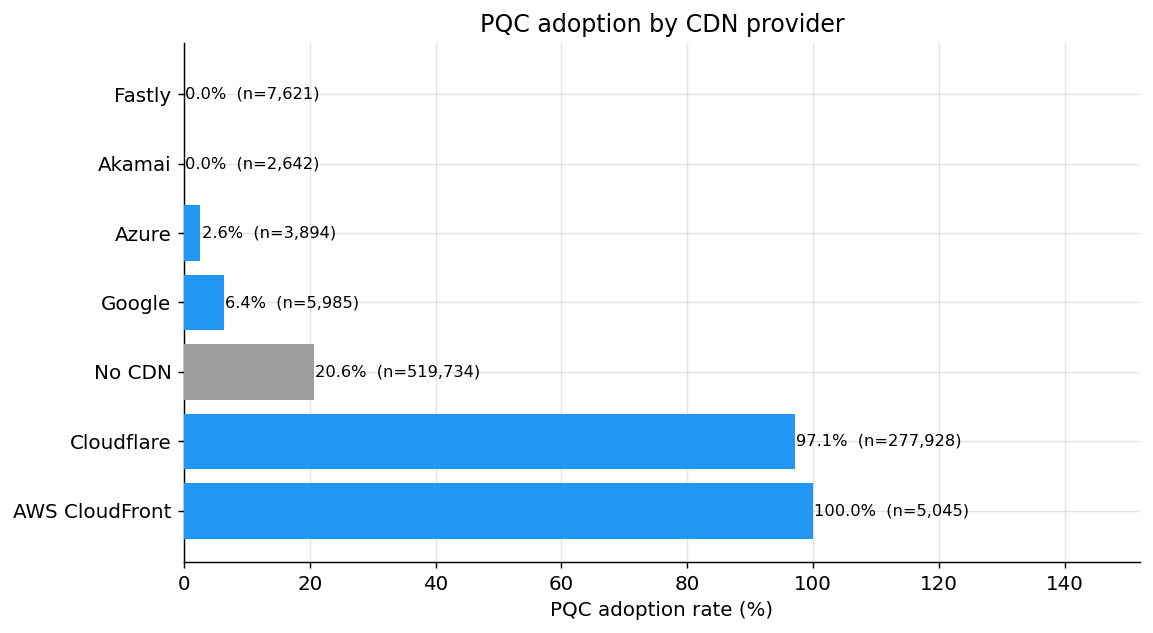

In [122]:
df_cdn = df.copy()
df_cdn['cdn_label'] = df_cdn['cdn_provider'].fillna('No CDN')
cdn = df_cdn.groupby('cdn_label')['has_pqc'].agg(['sum', 'count']).reset_index()
cdn.columns = ['cdn', 'pqc_count', 'total']
cdn['pqc_rate'] = cdn['pqc_count'] / cdn['total'] * 100
cdn = cdn.sort_values('pqc_rate', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colours = [PQC_COLOUR if c != 'No CDN' else '#9E9E9E' for c in cdn['cdn']]
hbar_chart(ax, cdn, 'cdn', 'PQC adoption by CDN provider', colours=colours)
plt.tight_layout()
plt.savefig('pqc_by_cdn.png', bbox_inches='tight')
plt.show()

## 11 — Adoption by country (top 20 by volume)

### Adoption by country — All domains

In [123]:
COUNTRY_NAMES = {
    'AF':'Afghanistan','AX':'Åland Islands','AL':'Albania','DZ':'Algeria',
    'AS':'American Samoa','AD':'Andorra','AO':'Angola','AI':'Anguilla',
    'AQ':'Antarctica','AG':'Antigua and Barbuda','AR':'Argentina','AM':'Armenia',
    'AW':'Aruba','AU':'Australia','AT':'Austria','AZ':'Azerbaijan',
    'BS':'Bahamas','BH':'Bahrain','BD':'Bangladesh','BB':'Barbados',
    'BY':'Belarus','BE':'Belgium','BZ':'Belize','BJ':'Benin',
    'BM':'Bermuda','BT':'Bhutan','BO':'Bolivia','BA':'Bosnia and Herzegovina',
    'BW':'Botswana','BV':'Bouvet Island','BR':'Brazil','IO':'British Indian Ocean Territory',
    'BN':'Brunei','BG':'Bulgaria','BF':'Burkina Faso','BI':'Burundi',
    'CV':'Cape Verde','KH':'Cambodia','CM':'Cameroon','CA':'Canada',
    'KY':'Cayman Islands','CF':'Central African Republic','TD':'Chad','CL':'Chile',
    'CN':'China','CX':'Christmas Island','CC':'Cocos Islands','CO':'Colombia',
    'KM':'Comoros','CG':'Congo','CD':'DR Congo','CK':'Cook Islands',
    'CR':'Costa Rica','CI':'Côte d\'Ivoire','HR':'Croatia','CU':'Cuba',
    'CW':'Curaçao','CY':'Cyprus','CZ':'Czechia','DK':'Denmark',
    'DJ':'Djibouti','DM':'Dominica','DO':'Dominican Republic','EC':'Ecuador',
    'EG':'Egypt','SV':'El Salvador','GQ':'Equatorial Guinea','ER':'Eritrea',
    'EE':'Estonia','SZ':'Eswatini','ET':'Ethiopia','FK':'Falkland Islands',
    'FO':'Faroe Islands','FJ':'Fiji','FI':'Finland','FR':'France',
    'GF':'French Guiana','PF':'French Polynesia','TF':'French Southern Territories',
    'GA':'Gabon','GM':'Gambia','GE':'Georgia','DE':'Germany',
    'GH':'Ghana','GI':'Gibraltar','GR':'Greece','GL':'Greenland',
    'GD':'Grenada','GP':'Guadeloupe','GU':'Guam','GT':'Guatemala',
    'GG':'Guernsey','GN':'Guinea','GW':'Guinea-Bissau','GY':'Guyana',
    'HT':'Haiti','HM':'Heard Island','VA':'Vatican','HN':'Honduras',
    'HK':'Hong Kong','HU':'Hungary','IS':'Iceland','IN':'India',
    'ID':'Indonesia','IR':'Iran','IQ':'Iraq','IE':'Ireland',
    'IM':'Isle of Man','IL':'Israel','IT':'Italy','JM':'Jamaica',
    'JP':'Japan','JE':'Jersey','JO':'Jordan','KZ':'Kazakhstan',
    'KE':'Kenya','KI':'Kiribati','KP':'North Korea','KR':'South Korea',
    'KW':'Kuwait','KG':'Kyrgyzstan','LA':'Laos','LV':'Latvia',
    'LB':'Lebanon','LS':'Lesotho','LR':'Liberia','LY':'Libya',
    'LI':'Liechtenstein','LT':'Lithuania','LU':'Luxembourg','MO':'Macao',
    'MG':'Madagascar','MW':'Malawi','MY':'Malaysia','MV':'Maldives',
    'ML':'Mali','MT':'Malta','MH':'Marshall Islands','MQ':'Martinique',
    'MR':'Mauritania','MU':'Mauritius','YT':'Mayotte','MX':'Mexico',
    'FM':'Micronesia','MD':'Moldova','MC':'Monaco','MN':'Mongolia',
    'ME':'Montenegro','MS':'Montserrat','MA':'Morocco','MZ':'Mozambique',
    'MM':'Myanmar','NA':'Namibia','NR':'Nauru','NP':'Nepal',
    'NL':'Netherlands','NC':'New Caledonia','NZ':'New Zealand','NI':'Nicaragua',
    'NE':'Niger','NG':'Nigeria','NU':'Niue','NF':'Norfolk Island',
    'MK':'North Macedonia','MP':'Northern Mariana Islands','NO':'Norway','OM':'Oman',
    'PK':'Pakistan','PW':'Palau','PS':'Palestine','PA':'Panama',
    'PG':'Papua New Guinea','PY':'Paraguay','PE':'Peru','PH':'Philippines',
    'PN':'Pitcairn','PL':'Poland','PT':'Portugal','PR':'Puerto Rico',
    'QA':'Qatar','RE':'Réunion','RO':'Romania','RU':'Russia',
    'RW':'Rwanda','BL':'Saint Barthélemy','SH':'Saint Helena',
    'KN':'Saint Kitts and Nevis','LC':'Saint Lucia','MF':'Saint Martin',
    'PM':'Saint Pierre and Miquelon','VC':'Saint Vincent and the Grenadines',
    'WS':'Samoa','SM':'San Marino','ST':'São Tomé and Príncipe','SA':'Saudi Arabia',
    'SN':'Senegal','RS':'Serbia','SC':'Seychelles','SL':'Sierra Leone',
    'SG':'Singapore','SX':'Sint Maarten','SK':'Slovakia','SI':'Slovenia',
    'SB':'Solomon Islands','SO':'Somalia','ZA':'South Africa',
    'GS':'South Georgia','SS':'South Sudan','ES':'Spain','LK':'Sri Lanka',
    'SD':'Sudan','SR':'Suriname','SJ':'Svalbard and Jan Mayen','SE':'Sweden',
    'CH':'Switzerland','SY':'Syria','TW':'Taiwan','TJ':'Tajikistan',
    'TZ':'Tanzania','TH':'Thailand','TL':'Timor-Leste','TG':'Togo',
    'TK':'Tokelau','TO':'Tonga','TT':'Trinidad and Tobago','TN':'Tunisia',
    'TR':'Turkey','TM':'Turkmenistan','TC':'Turks and Caicos Islands',
    'TV':'Tuvalu','UG':'Uganda','UA':'Ukraine','AE':'United Arab Emirates',
    'GB':'United Kingdom','US':'United States','UM':'US Minor Outlying Islands',
    'UY':'Uruguay','UZ':'Uzbekistan','VU':'Vanuatu','VE':'Venezuela',
    'VN':'Vietnam','VG':'British Virgin Islands','VI':'US Virgin Islands',
    'WF':'Wallis and Futuna','EH':'Western Sahara','YE':'Yemen',
    'ZM':'Zambia','ZW':'Zimbabwe',
}


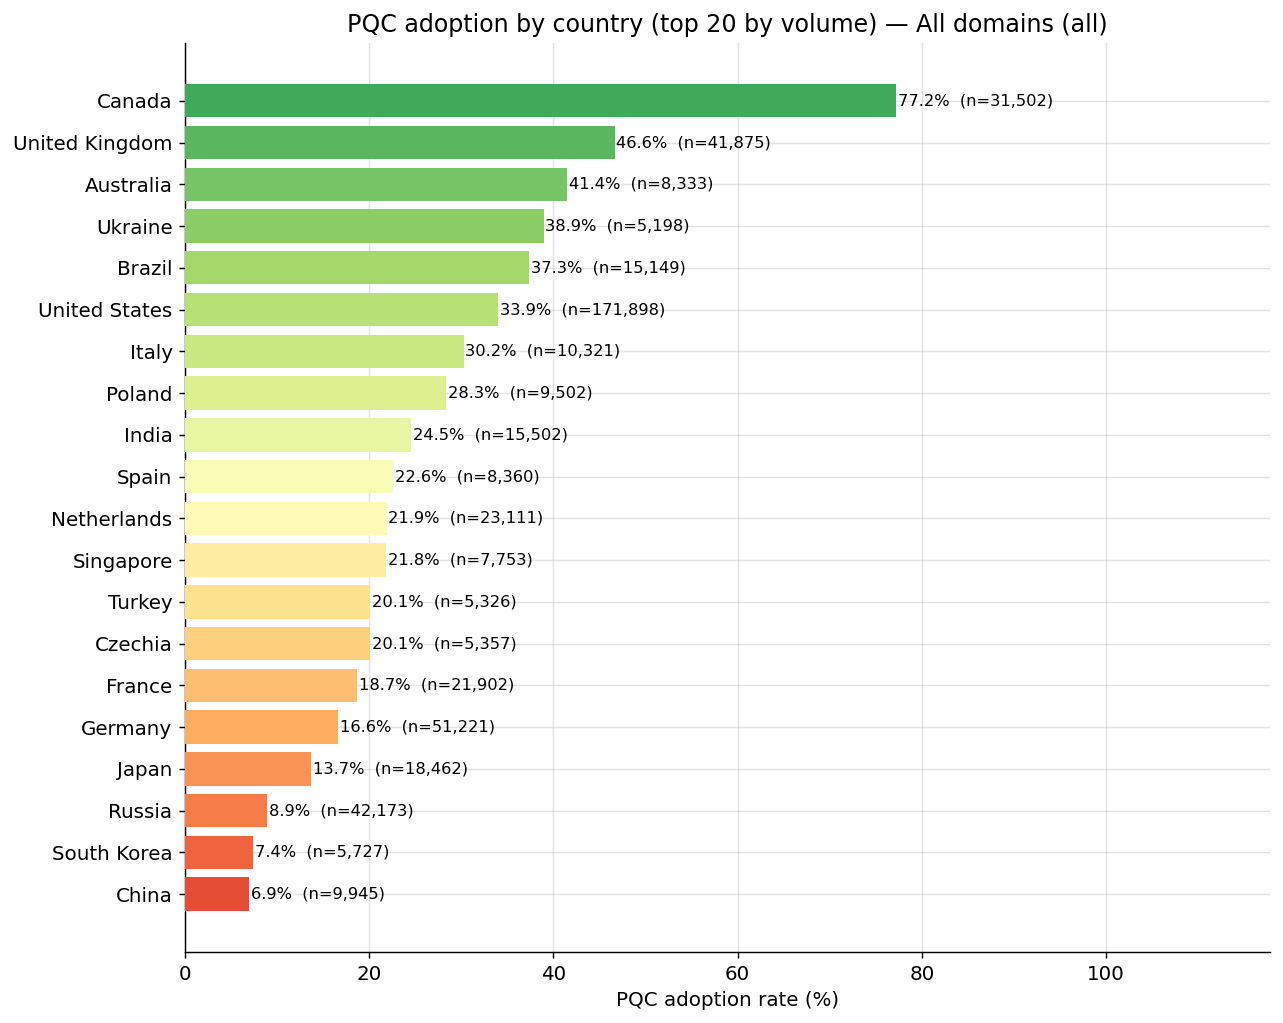

In [124]:
df_reg = apply_rank(df)
reg = adoption_by_col('region', df_reg, min_count=10)
reg = reg.nlargest(20, 'total').sort_values('pqc_rate', ascending=True)
reg['region'] = reg['region'].map(lambda c: COUNTRY_NAMES.get(str(c).upper(), c))

colours = list(plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(reg))))
fig, ax = plt.subplots(figsize=(10, 8))
hbar_chart(ax, reg, 'region', f'PQC adoption by country (top 20 by volume) — All domains ({rank_label})', colours=colours)
plt.tight_layout()
plt.savefig(f'pqc_by_region_all_{rank_label.replace(" ","_")}.png', bbox_inches='tight')
plt.show()

### Adoption by country — No-CDN domains

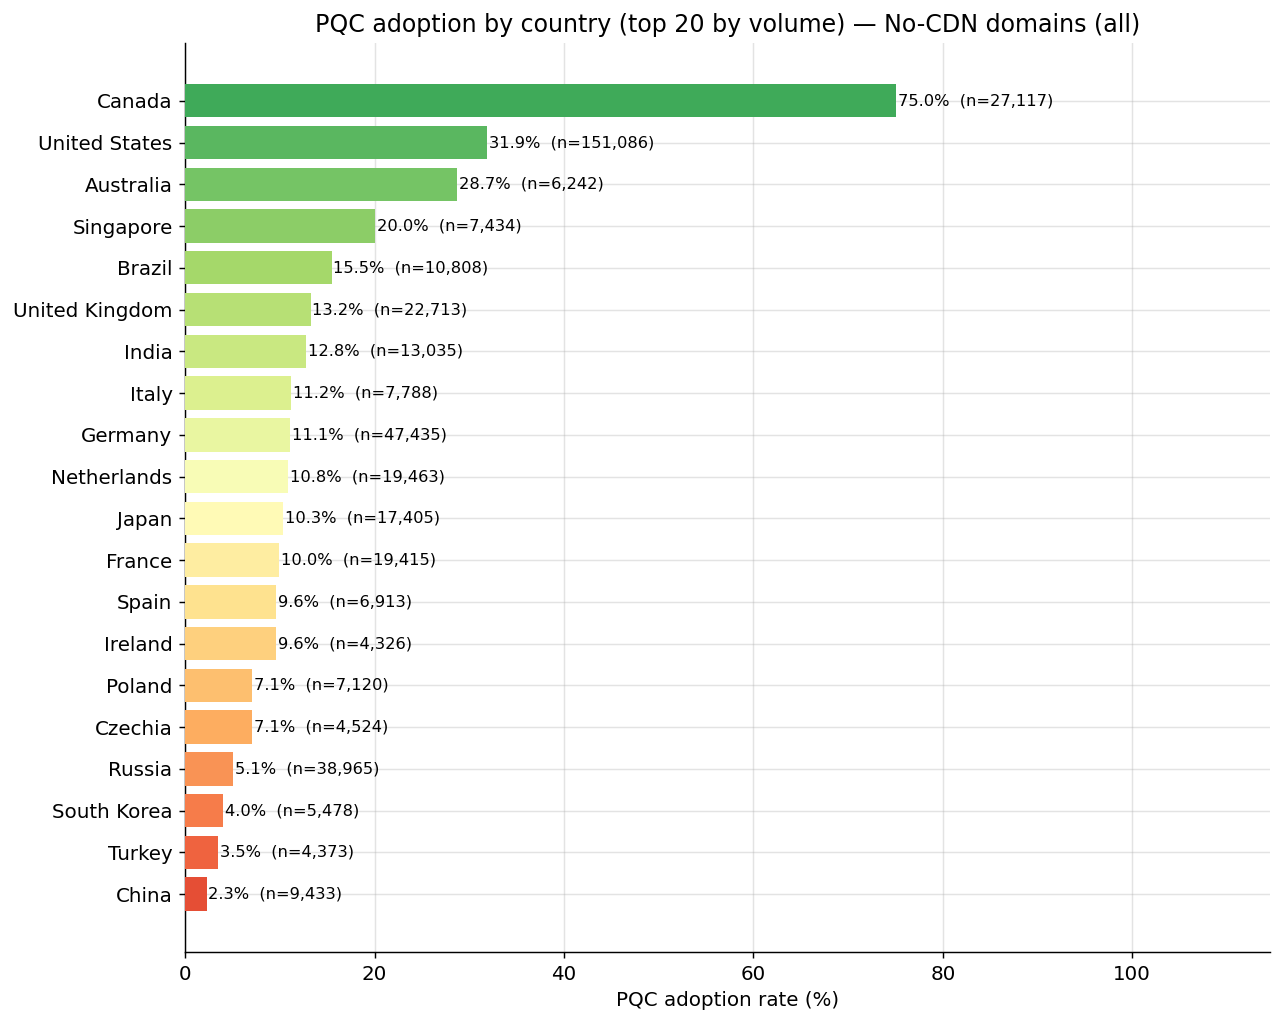

In [125]:
df_reg_nc = apply_rank(df_nocdn)
reg = adoption_by_col('region', df_reg_nc, min_count=10)
reg = reg.nlargest(20, 'total').sort_values('pqc_rate', ascending=True)
reg['region'] = reg['region'].map(lambda c: COUNTRY_NAMES.get(str(c).upper(), c))

colours = list(plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(reg))))
fig, ax = plt.subplots(figsize=(10, 8))
hbar_chart(ax, reg, 'region', f'PQC adoption by country (top 20 by volume) — No-CDN domains ({rank_label})', colours=colours)
plt.tight_layout()
plt.savefig(f'pqc_by_region_nocdn_{rank_label.replace(" ","_")}.png', bbox_inches='tight')
plt.show()

### Adoption by country — CDN-only domains

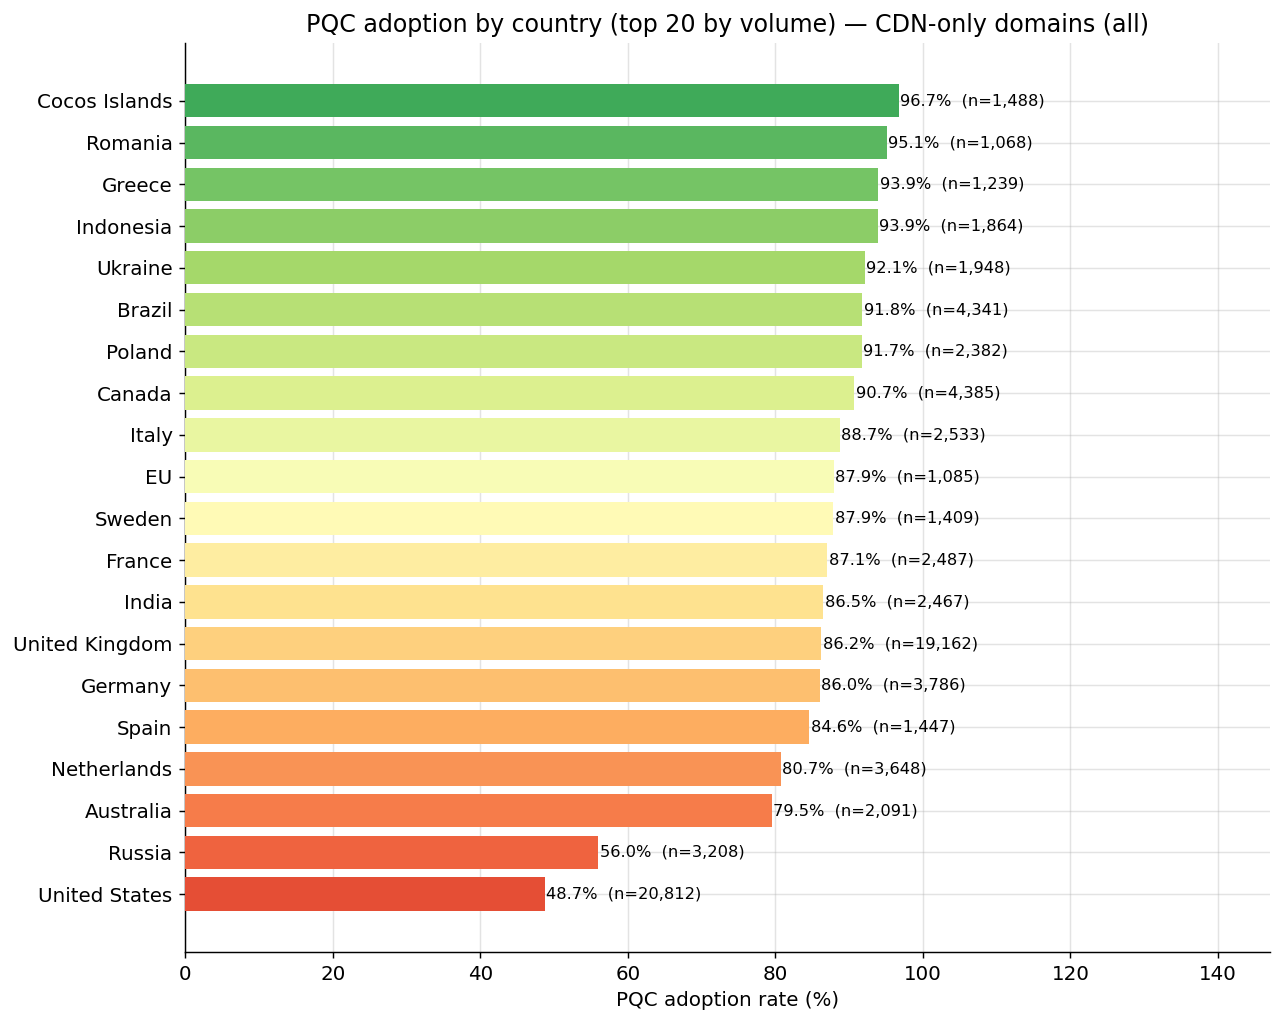

In [126]:
df_reg_cdn = apply_rank(df_cdnonly)
reg = adoption_by_col('region', df_reg_cdn, min_count=10)
reg = reg.nlargest(20, 'total').sort_values('pqc_rate', ascending=True)
reg['region'] = reg['region'].map(lambda c: COUNTRY_NAMES.get(str(c).upper(), c))

colours = list(plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(reg))))
fig, ax = plt.subplots(figsize=(10, 8))
hbar_chart(ax, reg, 'region', f'PQC adoption by country (top 20 by volume) — CDN-only domains ({rank_label})', colours=colours)
plt.tight_layout()
plt.savefig(f'pqc_by_region_cdnonly_{rank_label.replace(" ","_")}.png', bbox_inches='tight')
plt.show()

### Domain count by country (top 30)
Total good responses per country, regardless of PQC support.

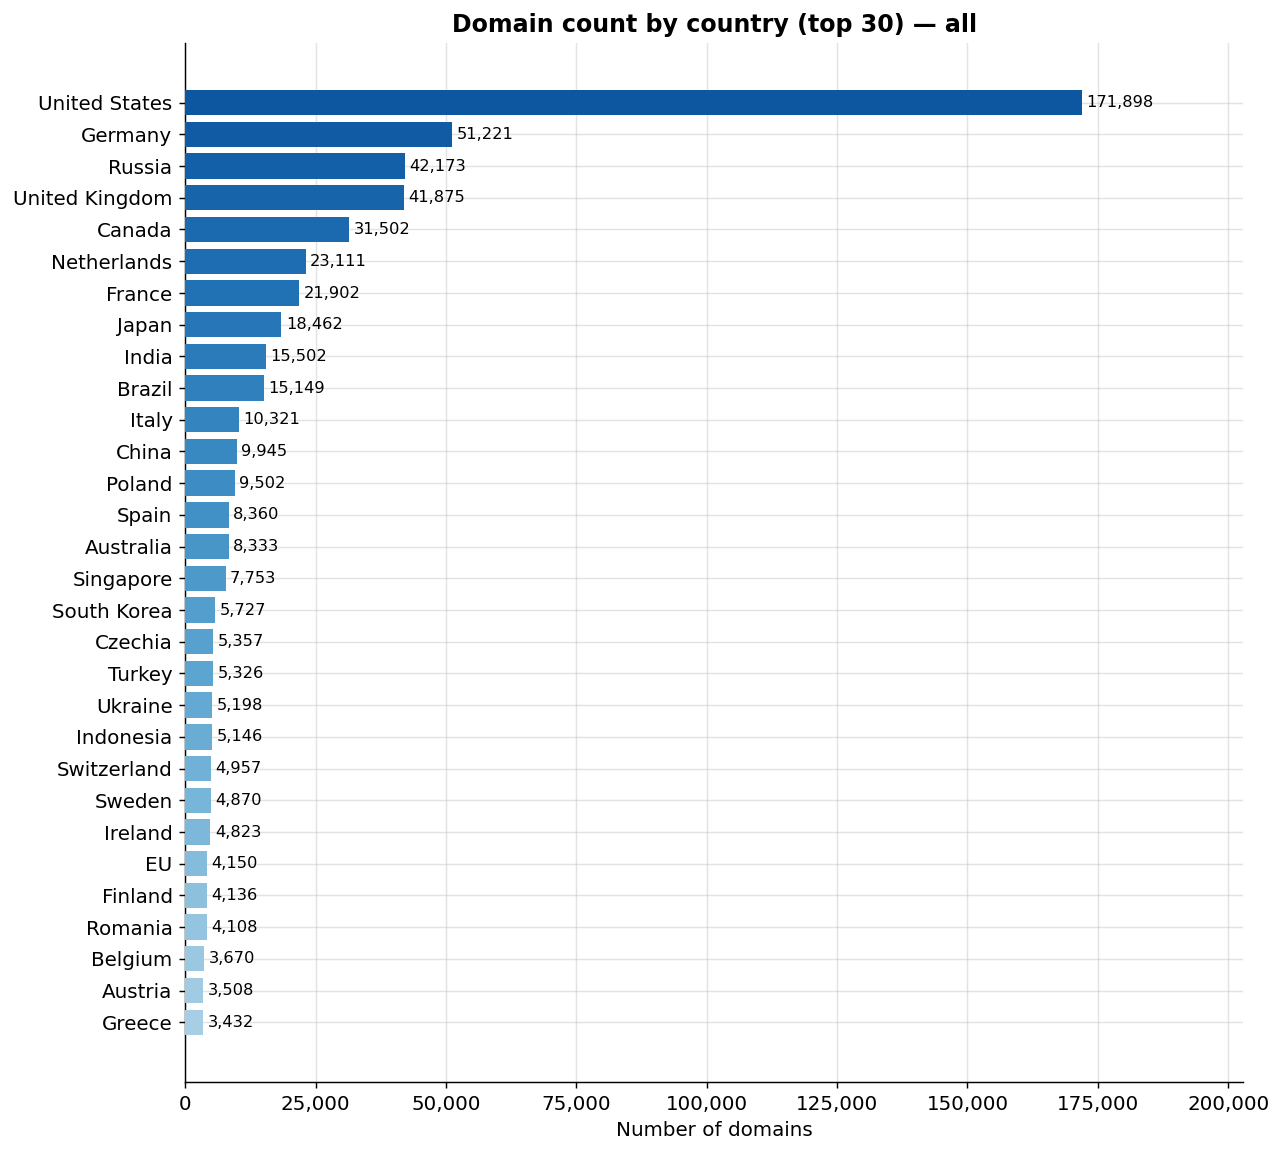

In [127]:
df_cnt = apply_rank(df)
_d = df_cnt[df_cnt['region'].notna() & (df_cnt['region'].astype(str) != 'None')].copy()
counts = (_d.groupby('region').size()
            .reset_index(name='total')
            .nlargest(30, 'total')
            .sort_values('total', ascending=True))
counts['region'] = counts['region'].map(lambda c: COUNTRY_NAMES.get(str(c).upper(), c))

colours = list(plt.cm.Blues(np.linspace(0.35, 0.85, len(counts))))
fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(counts['region'], counts['total'], color=colours, zorder=3)
for bar, val in zip(bars, counts['total']):
    ax.text(bar.get_width() + counts['total'].max()*0.005,
            bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.set_xlabel('Number of domains')
ax.set_xlim(0, counts['total'].max() * 1.18)
ax.set_title(f'Domain count by country (top 30) — {rank_label}', fontweight='bold')
plt.tight_layout()
plt.savefig(f'domain_count_by_country_{rank_label.replace(" ","_")}.png', bbox_inches='tight')
plt.show()

## 13 — Cross-factor heatmaps
**Region × Sector**: PQC adoption rate (%) at every country/sector intersection.

**CDN × PQC status**: for each CDN provider (and No CDN), what share of its domains have PQC enabled vs not.

### Region × Sector — PQC adoption rate

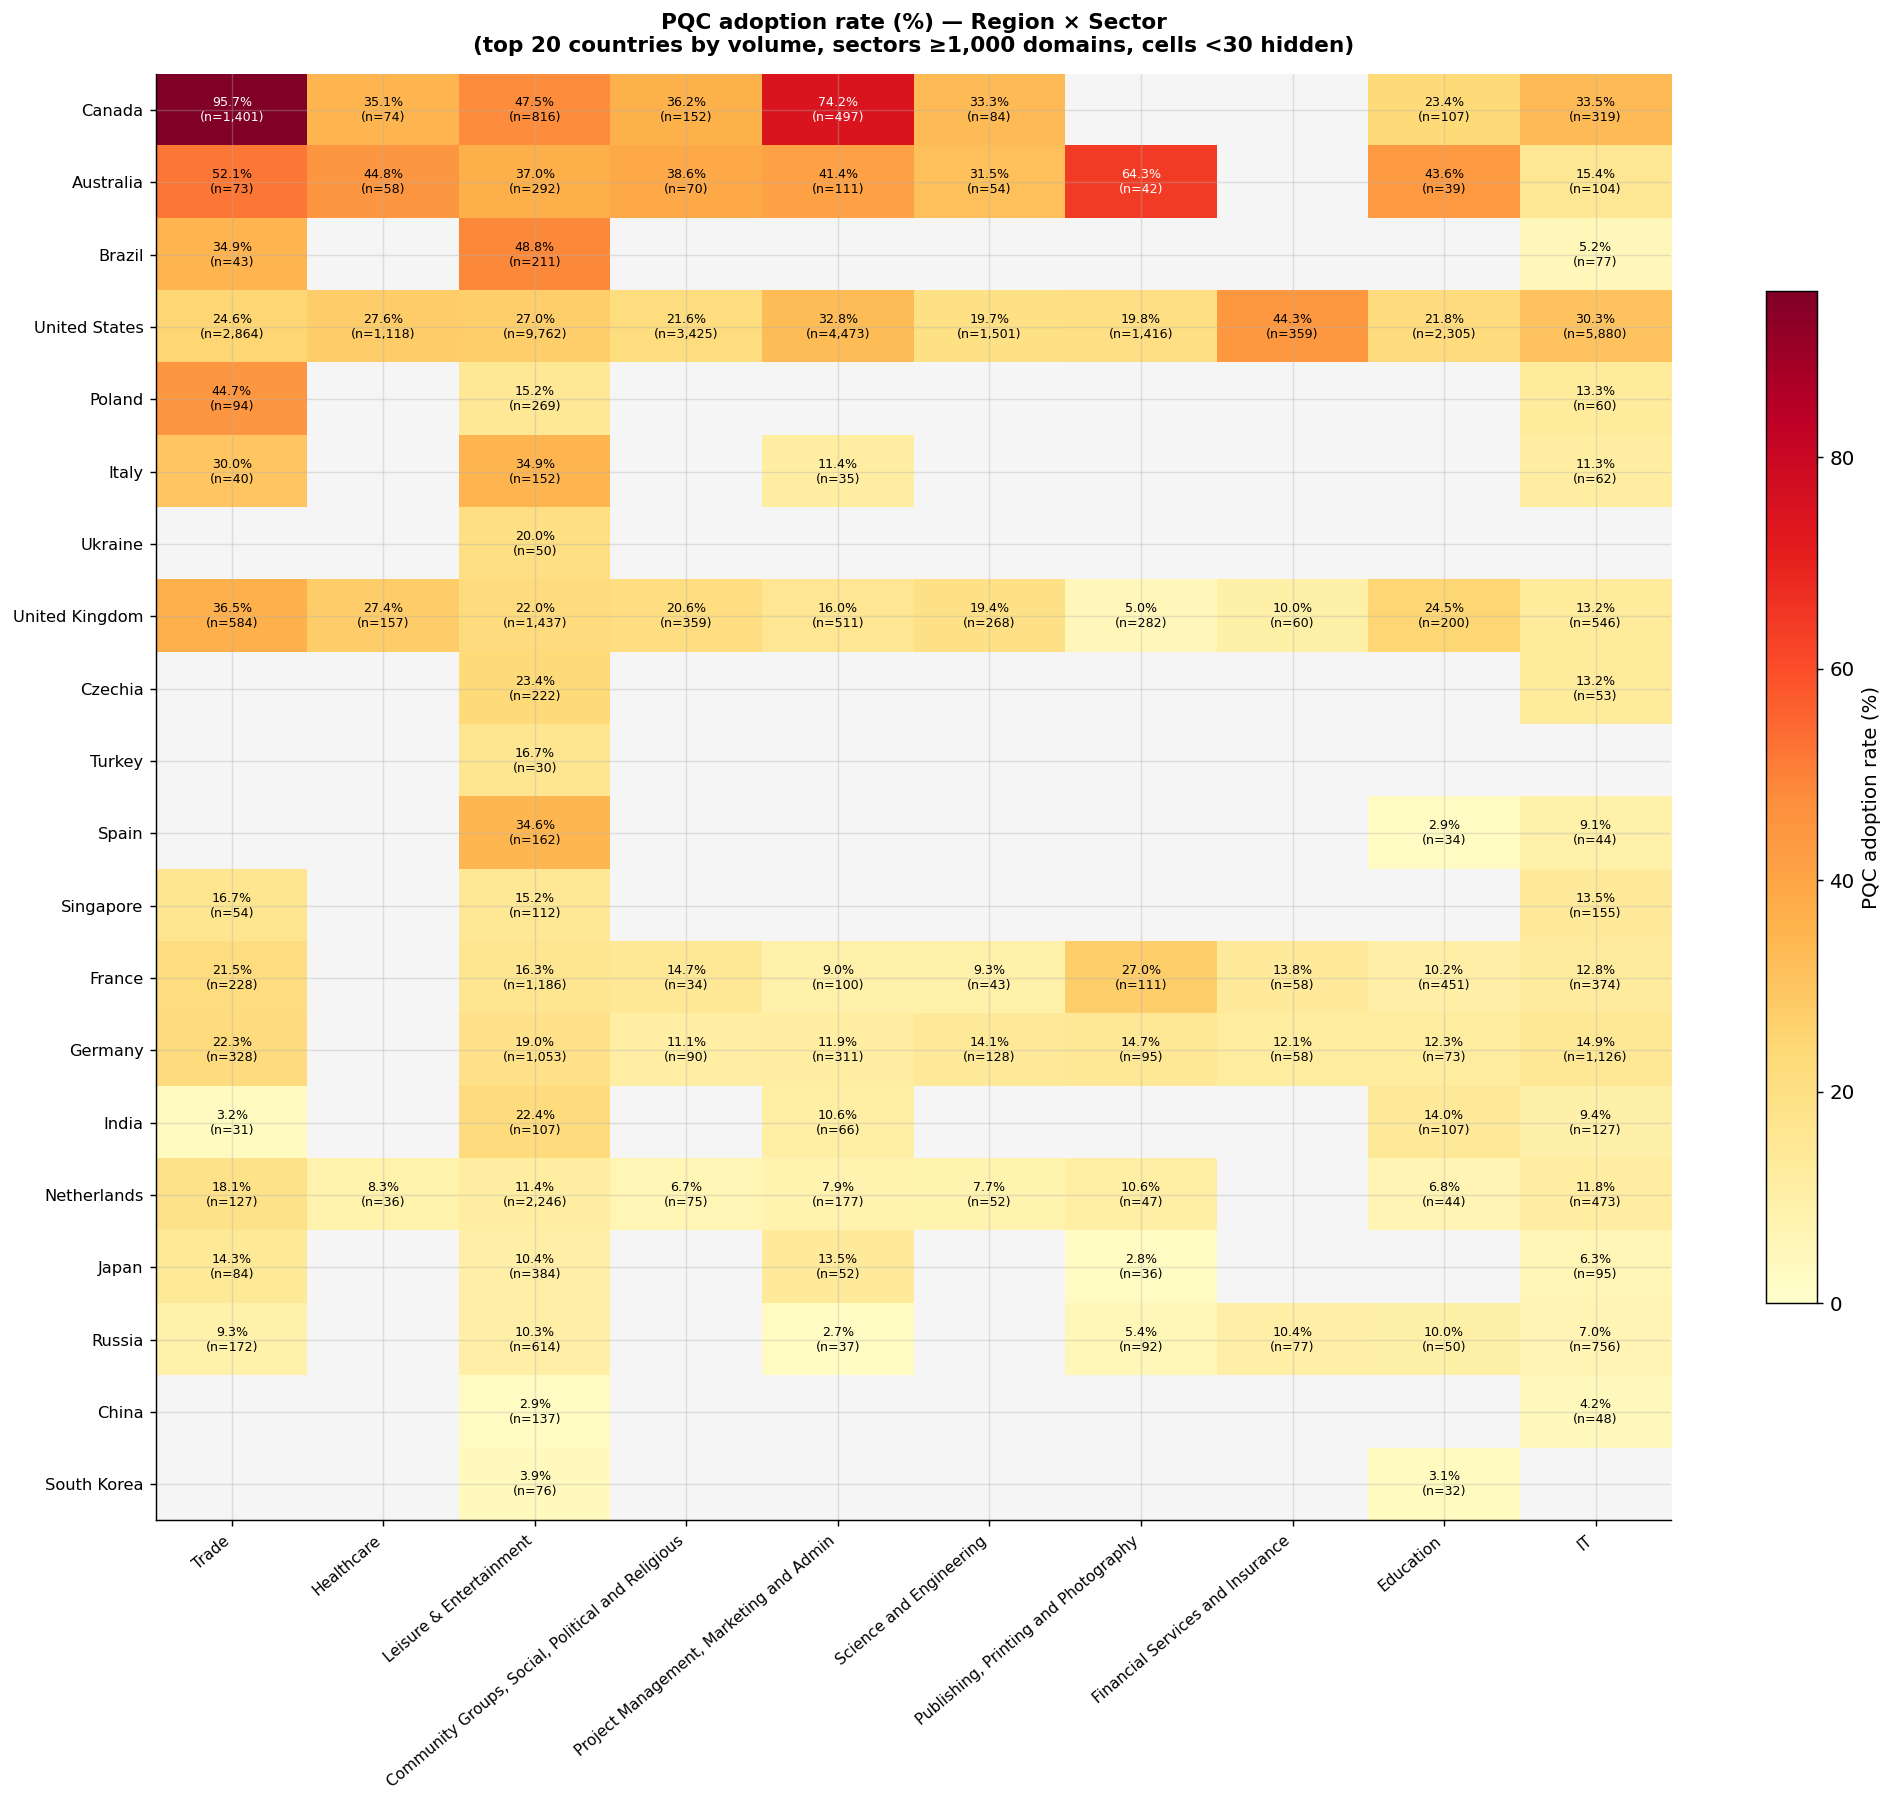

In [128]:
MIN_CELL = 30  # cells with fewer domains are left blank

_d = df.copy()
_d = _d[_d['region'].notna() & (_d['region'].astype(str) != 'None')]
_d = _d[_d['sector'].notna()  & (_d['sector'].astype(str)  != 'None')]
_d['region_name'] = _d['region'].map(lambda c: COUNTRY_NAMES.get(str(c).upper(), c))

# restrict to top 20 countries and sectors with >=1000 domains overall
_top_countries = (df[df['region'].notna()]
                  .groupby('region').size()
                  .nlargest(20).index
                  .map(lambda c: COUNTRY_NAMES.get(str(c).upper(), c)))
_top_sectors = (df[df['sector'].notna()]
                .groupby('sector').size()
                .pipe(lambda s: s[s >= 1000]).index.tolist())

_d = _d[_d['region_name'].isin(_top_countries) & _d['sector'].isin(_top_sectors)]

grp = (_d.groupby(['region_name', 'sector'])['has_pqc']
         .agg(['sum', 'count']).reset_index())
grp.columns = ['region', 'sector', 'pqc', 'total']
grp.loc[grp['total'] < MIN_CELL, ['pqc', 'total']] = float('nan')
grp['rate'] = grp['pqc'] / grp['total'] * 100

rate_piv  = grp.pivot(index='region',  columns='sector', values='rate')
count_piv = grp.pivot(index='region', columns='sector', values='total')

row_order = rate_piv.mean(axis=1).sort_values(ascending=False).index
col_order = rate_piv.mean(axis=0).sort_values(ascending=False).index
rate_piv  = rate_piv.reindex(index=row_order, columns=col_order)
count_piv = count_piv.reindex(index=row_order, columns=col_order)

nrows, ncols = rate_piv.shape
fig, ax = plt.subplots(figsize=(max(14, ncols * 1.4 + 2), max(8, nrows * 0.6 + 2)))
masked = np.ma.masked_invalid(rate_piv.values.astype(float))
cmap = plt.cm.YlOrRd.copy()
cmap.set_bad('whitesmoke')
im = ax.imshow(masked, aspect='auto', cmap=cmap, vmin=0)
plt.colorbar(im, ax=ax, label='PQC adoption rate (%)', shrink=0.7)

ax.set_xticks(range(ncols))
ax.set_xticklabels(rate_piv.columns, rotation=40, ha='right', fontsize=8.5)
ax.set_yticks(range(nrows))
ax.set_yticklabels(rate_piv.index, fontsize=9)

vmax = float(np.nanmax(masked))
for i in range(nrows):
    for j in range(ncols):
        rate = rate_piv.values[i, j]
        cnt  = count_piv.values[i, j]
        if np.isnan(rate):
            continue
        txt_col = 'white' if rate > vmax * 0.65 else 'black'
        ax.text(j, i, f'{rate:.1f}%\n(n={int(cnt):,})',
                ha='center', va='center', fontsize=7, color=txt_col)

ax.set_title('PQC adoption rate (%) — Region × Sector\n'
             f'(top 20 countries by volume, sectors ≥1,000 domains, cells <{MIN_CELL} hidden)',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('heatmap_region_sector.png', bbox_inches='tight')
plt.show()

### CDN provider × PQC adoption status

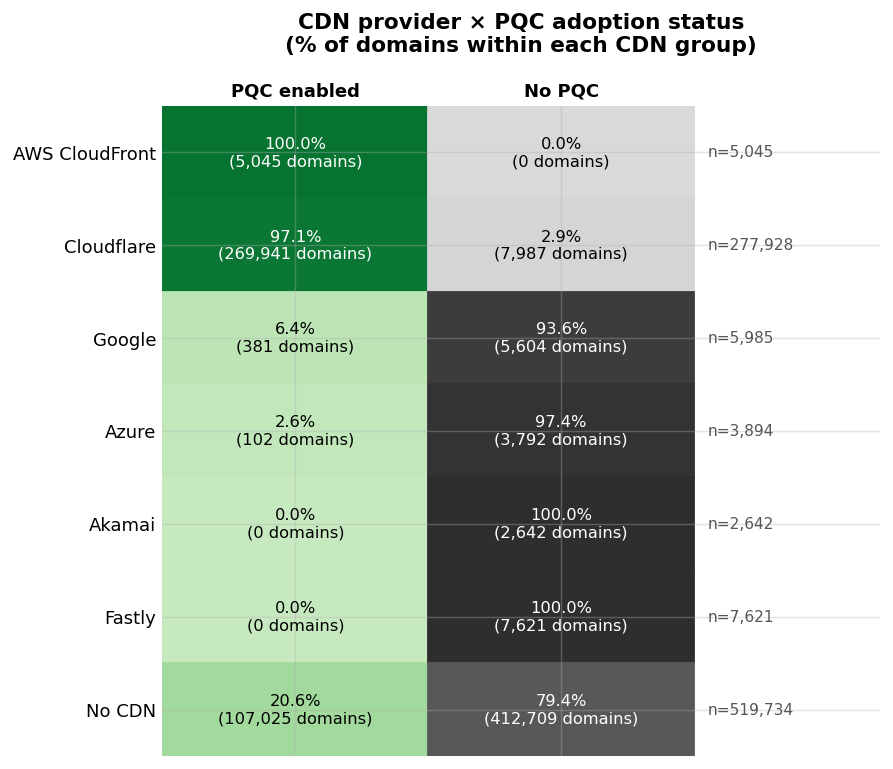

In [129]:
_dc = df.copy()
_dc['cdn_label'] = _dc['cdn_provider'].fillna('No CDN')
_dc['pqc_label'] = _dc['has_pqc'].map({True: 'PQC enabled', False: 'No PQC'})

ct = (_dc.groupby(['cdn_label', 'pqc_label'])
         .size().reset_index(name='count'))
totals = _dc.groupby('cdn_label').size().rename('cdn_total')
ct = ct.merge(totals, on='cdn_label')
ct['pct'] = ct['count'] / ct['cdn_total'] * 100

pct_piv   = ct.pivot(index='cdn_label', columns='pqc_label', values='pct').fillna(0)
count_piv = ct.pivot(index='cdn_label', columns='pqc_label', values='count').fillna(0)
total_s   = _dc.groupby('cdn_label').size()  # Series: cdn -> total domains

# ensure both columns exist even if one PQC bucket is empty for a CDN
for col in ['PQC enabled', 'No PQC']:
    if col not in pct_piv.columns:
        pct_piv[col]   = 0.0
        count_piv[col] = 0

# order rows by PQC-enabled % descending; No CDN always last
order = pct_piv['PQC enabled'].sort_values(ascending=False).index.tolist()
if 'No CDN' in order:
    order = [x for x in order if x != 'No CDN'] + ['No CDN']
pct_piv   = pct_piv.reindex(order)
count_piv = count_piv.reindex(order)

col_order = ['PQC enabled', 'No PQC']
pct_piv   = pct_piv[col_order]
count_piv = count_piv[col_order]

nrows, ncols = pct_piv.shape
fig, ax = plt.subplots(figsize=(7, max(4, nrows * 0.65 + 1.5)))

CELL_CMAPS = {'PQC enabled': plt.cm.Greens, 'No PQC': plt.cm.Greys}

for j, col in enumerate(col_order):
    vals  = pct_piv[col].values.astype(float)
    cnts  = count_piv[col].values.astype(float)
    vmin, vmax_col = np.nanmin(vals), np.nanmax(vals)
    norm_vals = (vals - vmin) / (vmax_col - vmin + 1e-9)
    for i, (pct, norm, cnt) in enumerate(zip(vals, norm_vals, cnts)):
        colour  = CELL_CMAPS[col](0.25 + norm * 0.6)
        ax.add_patch(plt.Rectangle((j, i), 1, 1, color=colour))
        luma    = 0.299*colour[0] + 0.587*colour[1] + 0.114*colour[2]
        txt_col = 'white' if luma < 0.55 else 'black'
        cnt_str = f'{int(cnt):,}' if not np.isnan(cnt) else '—'
        ax.text(j + 0.5, i + 0.5,
                f'{pct:.1f}%\n({cnt_str} domains)',
                ha='center', va='center', fontsize=9, color=txt_col)

for i, cdn in enumerate(order):
    tot = int(total_s.get(cdn, 0))
    ax.text(ncols + 0.05, i + 0.5, f'n={tot:,}',
            va='center', fontsize=8.5, color='#555')

ax.set_xlim(0, ncols + 0.7)
ax.set_ylim(0, nrows)
ax.set_xticks([j + 0.5 for j in range(ncols)])
ax.set_xticklabels(col_order, fontsize=10, fontweight='bold')
ax.set_yticks([i + 0.5 for i in range(nrows)])
ax.set_yticklabels(order, fontsize=10)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.invert_yaxis()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)
ax.set_title('CDN provider × PQC adoption status\n'
             '(% of domains within each CDN group)',
             fontsize=12, fontweight='bold', pad=30)
plt.tight_layout()
plt.savefig('heatmap_cdn_pqc.png', bbox_inches='tight')
plt.show()

## 12 — PQC protocol distribution

### Protocol distribution — All domains

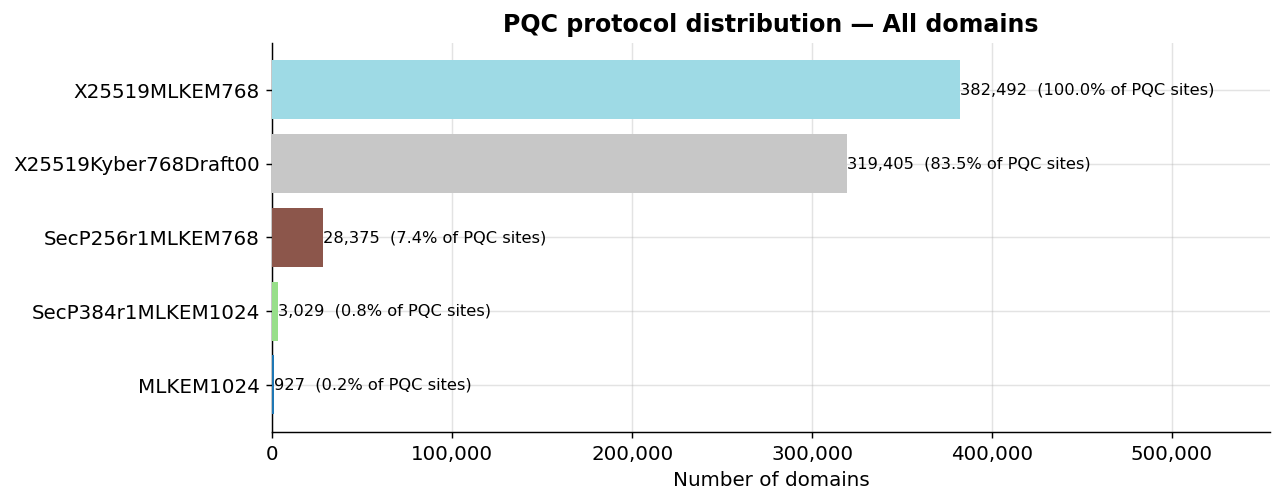

In [130]:
if df_proto.empty:
    print('No protocol data.')
else:
    _pqc_total = int((df)['has_pqc'].sum())
    counts = (df_proto.drop_duplicates(subset=['domain_rank','protocol_name'])
                         .groupby('protocol_name').size().sort_values(ascending=True))
    pcts   = counts / _pqc_total * 100

    fig, ax = plt.subplots(figsize=(10, max(4, len(counts)*0.55+1)))
    colours = [CMAP(i) for i in np.linspace(0, 1, len(counts))]
    bars = ax.barh(counts.index, counts.values, color=colours, zorder=3)
    for bar, val, pct in zip(bars, counts.values, pcts):
        ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                f'{val:,}  ({pct:.1f}% of PQC sites)', va='center', fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))
    ax.set_xlabel('Number of domains')
    ax.set_xlim(0, counts.max()*1.45)
    ax.set_title('PQC protocol distribution — All domains', fontweight='bold')
    plt.tight_layout()
    plt.savefig('pqc_protocols_all.png', bbox_inches='tight')
    plt.show()

## 16 — Cleanup

In [131]:
cursor.close()
conn.close()
print('Connection closed.')

Connection closed.
